In [3]:
! pip install pdfplumber

  Using cached pdfplumber-0.11.9-py3-none-any.whl.metadata (43 kB)
  Using cached pdfminer_six-20251230-py3-none-any.whl.metadata (4.3 kB)
Using cached pdfplumber-0.11.9-py3-none-any.whl (60 kB)
Using cached pdfminer_six-20251230-py3-none-any.whl (6.6 MB)
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------- ----------------------- 1.6/3.7 MB 10.2 MB/s eta 0:00:01
   ---------------------- ----------------- 2.1/3.7 MB 5.3 MB/s eta 0:00:01
   ---------------------------- ----------- 2.6/3.7 MB 4.2 MB/s eta 0:00:01
   --------------------------------- ------ 3.1/3.7 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------  3.7/3.7 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 3.7/3.7 MB 3.3 MB/s eta 0:00:00

   ---------------------------------------- 0/3 [pypdfium2]
   ------------- -------------------------- 1/3 [pdfminer.six]
   ------------- -------------------------- 1/3 [pdfminer.six]
   ----------------------------

In [3]:
import pdfplumber
import unicodedata
import re
import pandas as pd
import string
import matplotlib.pyplot as plt
import seaborn as sns
from AtakapaHFBuilder import AtakapaDatasetBuilder
from datasets import concatenate_datasets

# Dataset Construction and EDA

Before we can begin, we will have to construct our data sets. The information available to us are found in a dictionary and a reference grammar. The first data set we will construct will be the morphology data set. This data set will be constructed manually, since it requires a deep knowledge of the language itself and will not be easily extracted programmatically. 

## Importing Morphology File

In [34]:
morph = pd.read_excel('atakapa_morphology_UTF8.xlsx')
morph.head()

,rule_id,slot_position,paradigm_set,affix_type,target_pos,required_features,environment_condition,morpheme_action,gloss_tag
0,ACT_1PL,15,Active_Suffix_Set,Suffix,Verb,active,NaN,-cel,1PL_SUBJ
1,ACT_1PLIMP,15,Active_Suffix_Set,Suffix,Verb,active,NaN,-lo,1PL_IMP
2,ACT_1SG,15,Active_Suffix_Set,Suffix,Verb,active,NaN,-o,1SG_SUBJ
3,ACT_2PL,15,Active_Suffix_Set,Suffix,Verb,active,NaN,-tem,2PL_SUBJ
4,ACT_2PLIMP,15,Active_Suffix_Set,Suffix,Verb,active,NaN,-to,2PL_IMP


In [36]:
morph.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   rule_id                74 non-null     str  
 1   slot_position          74 non-null     int64
 2   paradigm_set           74 non-null     str  
 3   affix_type             74 non-null     str  
 4   target_pos             74 non-null     str  
 5   required_features      17 non-null     str  
 6   environment_condition  14 non-null     str  
 7   morpheme_action        74 non-null     str  
 8   gloss_tag              74 non-null     str  
dtypes: int64(1), str(8)
memory usage: 8.7 KB


## Creating Examples Data Set

Next we are going to extract and create the Examples Data Set. For this, we are going to use a pdf of "Yuhkíti Kóy: A Reference Grammar of the Atakapa Language" compiled by Geoffrey Kimball, Ph.D. which was provided by Dr. Kimball to aid in revitalization efforts. 

In [3]:
def convert_pdf_to_layout_text(pdf_path, output_txt_path):
    with pdfplumber.open(pdf_path) as pdf, open(output_txt_path, 'w', encoding='utf-8') as out_file:
        for page in pdf.pages:
            text = page.extract_text(layout=True)
            if text:
                out_file.write(text)

pdf_path = "Kimball Grammar.pdf"
output_path = "Kimball_Grammar_Layout_Preserved.txt"

convert_pdf_to_layout_text(pdf_path, output_path)

### Extracting Examples

In [4]:
def extract_atakapa_examples_v9(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        text_content = f.read()

    transcription_pattern = r"(?:[\[{/][^\]}/]{1,250}[\]}/]\s*)*"
    
    pattern_str = (
        r"("
        r"^[ \t]*" + transcription_pattern + r"\d+[ \t]*\)[ \t]+(?=[^\s\d])"
        r"(?:(?!\n[ \t]*" + transcription_pattern + r"\d+[ \t]*\)[ \t]+(?=[^\s\d])).){1,1500}?"
        r"\((?:1932|1885a?b?c?|1928|Gatschet)[^)]*\)"
        r")"
    )
    
    pattern = re.compile(pattern_str, re.DOTALL | re.IGNORECASE | re.MULTILINE)
    
    raw_matches = pattern.findall(text_content)
    
    corpus_data = []
    for match in raw_matches:
       
        cleaned_block = match.replace('--- PAGE BREAK ---', '')
        cleaned_block = re.sub(r'\n\s*\d+\s*\n', '\n', cleaned_block) # Drops isolated page numbers
        
        cleaned_block = re.sub(r'\n{3,}', '\n\n', cleaned_block.strip())
        corpus_data.append({"Raw_Example_Block": cleaned_block})
        
    df = pd.DataFrame(corpus_data)
    return df

input_path = "Kimball_Grammar_Layout_Preserved.txt"
v9_raw_df = extract_atakapa_examples_v9(input_path)

print(f"Successfully extracted {len(v9_raw_df)} examples!")

v9_raw_df.to_csv("Atakapa_Raw_Examples_v9.csv", index=False, encoding='utf-8')

Successfully extracted 430 examples!


### Converting Extracted Samples to Dataframe

In [5]:
df = pd.read_csv("Atakapa_Raw_Examples_v9.csv")

parsed_data = []

for index, row in df.iterrows():
    block = str(row['Raw_Example_Block']).strip()
    
    lines = [line.strip() for line in block.split('\n') if line.strip()]
    
    example_num = ""
    transcription = []
    phonemic = ""
    gloss = []
    translation = ""
    
    phonemic_idx = -1
    
    for i, line in enumerate(lines):
        match = re.match(r'^(\d+)\s*\)\s*(.*)', line)
        if match:
            example_num = match.group(1)
            phonemic = match.group(2)
            phonemic_idx = i
            break
            
    if phonemic_idx != -1:
        transcription = lines[:phonemic_idx]
        translation_idx = -1
        
        for i in range(phonemic_idx + 1, len(lines)):
            if re.match(r"^['\"‘“]", lines[i]):
                translation_idx = i
                break
                
        if translation_idx == -1:
            translation_idx = len(lines) - 1
            
        gloss = lines[phonemic_idx + 1 : translation_idx]
        
        translation = " ".join(lines[translation_idx:])
        
    else:
        translation = block
        
    parsed_data.append({
        "Example_Number": example_num,
        "Gatschet&Swanton": "\n".join(transcription),
        "Modern_Ortho": phonemic,
        "Gloss": "\n".join(gloss),
        "Translation": translation,
        "Raw_Block": block
    })

parsed_df = pd.DataFrame(parsed_data)
parsed_df.to_csv("Atakapa_Parsed_Corpus.csv", index=False, encoding='utf-8')

print(f"Successfully parsed {len(parsed_df)} examples into columns!")
parsed_df.head(10)

Successfully parsed 430 examples into columns!


,Example_Number,Gatschet&Swanton,Modern_Ortho,Gloss,Translation,Raw_Block
0,1,[icak taˊ-ic oˊkiăn yukitnē mon ialpeˊhiulĕt],iša·k táyš ókya yukit né· mo·n yálpéhiulat,iša·k tayš ok=ya yukit ne· mo·n\n...,‘Strange people have come and completely taken...,[icak taˊ-ic oˊkiăn yukitnē mon ialpeˊhiulĕt] ...
1,2,[uctiˊkit],ùštikit,ø-uš-tikit\n3STATS-be.so-FUT,‘It will be so.’ (1932:139:2),[uctiˊkit] ...
2,3,[hikuˊ wi nuˊk tik iˊka koˊ],hikú wi núk tikhikàkóh,hiku wi nuk tik-hi-ka-koh\nsoup I self g...,‘I myself want to go and make soup.’ (1932:41:1),[hikuˊ wi nuˊk tik iˊka koˊ] ...
3,4,[na ˊ-ic ĕncoˊkoi],náiš n̥šokòy,na-iš n̥-šokòy\nyou(sg)-FOC 2STATS-be.chief,‘You are a chief.’ (1932:83:1),[na ˊ-ic ĕncoˊkoi] ...
4,5,,há·š šokòy,ha-iš ø-šokòy\nhe-foc 3STATS-be.chief,‘He is a chief.’ (1932:69:1),5) há·š šokòy ...
5,6,[hikīˊke iˊcak],hikí·ke išà·k,hiki-ike ø-išà·k\nwest-EL 3STATS-be.person,‘He is a man from the west.’ (1932:40:2),[hikīˊke iˊcak] ...
6,7,[Taˊkapo kic yukiˊti nuˊnkin kēˊt’ntat],tákapa kìš yukhíti núŋkin ké·tn̥ tat,takapa ø-kìš yukhiti nuŋ-kin k...,"‘She was an Atakapa woman, and she used to liv...",[Taˊkapo kic yukiˊti nuˊnkin kēˊt’ntat] ...
7,8,[viˊvulat],wíwulat,wíw-ul-at\nbelieve-3PLS-PRET,‘They believed it.’ (1932:18:121),[viˊvulat] ...
8,9,[ok-inaˊtsûlat],hokináculat,hok-inác-ul-at\nRECIP-fight-3PLS-PRET,‘They fought each other.’ (1932:20:144),[ok-inaˊtsûlat] ...
9,10,[laˊwi-ulat],láwiulat,láw-i-ul-at\nburn-CAUS-3PLS-PRET,‘They burned it.’ (1932:19:138),[laˊwi-ulat] ...


### Check for missing examples

In [9]:
# Load your perfectly parsed dataset
examples = pd.read_csv("Atakapa_Parsed_Corpus.csv")

In [10]:
examples.info()

<class 'pandas.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Example_Number    430 non-null    int64
 1   Gatschet&Swanton  392 non-null    str  
 2   Modern_Ortho      430 non-null    str  
 3   Gloss             424 non-null    str  
 4   Translation       430 non-null    str  
 5   Raw_Block         430 non-null    str  
dtypes: int64(1), str(5)
memory usage: 450.0 KB


In [12]:
extracted_nums = pd.to_numeric(examples['Example_Number'], errors='coerce').dropna().astype(int).tolist()

extracted_set = set(extracted_nums)
max_num = max(extracted_set) if extracted_set else 0

perfect_set = set(range(1, max_num + 1))

missing_nums = sorted(list(perfect_set - extracted_set))

print(f"Highest example number found: {max_num}")
print(f"Total successfully extracted: {len(extracted_set)}")
print(f"Total missing entries: {len(missing_nums)}\n")

print("Here are the specific example numbers you need to manually add:")
for i in range(0, len(missing_nums), 10):
    print(", ".join(map(str, missing_nums[i:i+10])))

Highest example number found: 532
Total successfully extracted: 427
Total missing entries: 105

Here are the specific example numbers you need to manually add:
22, 28, 31, 36, 52, 54, 56, 63, 70, 73
76, 78, 88, 92, 105, 110, 121, 125, 137, 138
145, 154, 156, 162, 166, 168, 177, 189, 190, 191
195, 199, 206, 218, 219, 220, 223, 237, 240, 243
247, 250, 254, 260, 264, 265, 269, 279, 280, 281
282, 283, 284, 285, 286, 287, 288, 289, 290, 291
293, 294, 295, 296, 299, 300, 303, 311, 312, 316
325, 334, 338, 341, 352, 355, 362, 383, 398, 402
403, 404, 405, 409, 413, 424, 427, 434, 438, 441
444, 445, 449, 450, 456, 460, 477, 491, 500, 510
514, 518, 529, 530, 531


|======================================================================================================|
Now there will need to be some manual clean up. There are some inconsistencies in some of the glosses which must be addressed such as a lack of accents. Also, there are a number of examples in which Kimball analyzes a word that has become cemented as a single semantic unit in order to so the derivational morphology / compounding which produced a word, albeit inconsistently. Where he does, it makes sense to in the context of the grammar, however, since Kimball does not do this in all examples, these words will be treated as an unanalyzed lexeme; the glosses will be updated to reflect this.
|======================================================================================================|

In [12]:
def get_graphemes(s):
    """Splits a string into graphemes (base character + any combining marks)."""
    if pd.isna(s): return []
    s = unicodedata.normalize('NFC', str(s))
    graphemes = []
    for char in s:
        if unicodedata.category(char).startswith('M') and graphemes:
            graphemes[-1] += char
        else:
            graphemes.append(char)
    return graphemes

def transfer_accents(modern_ortho, gloss5):
    if pd.isna(modern_ortho) or pd.isna(gloss5):
        return gloss5
        
    g5_tokens = re.split(r'(\s+)', str(gloss5))
    mo_words = [w for w in re.split(r'\s+', str(modern_ortho)) if w]
    g5_words = [t for t in g5_tokens if not t.isspace() and t != '']
    
    # Safety Check 1: Do they have the same number of words?
    if len(mo_words) != len(g5_words):
        return gloss5 
        
    new_g5_words = []
    
    # Markers and dummy morphemes to ignore when mapping letters
    markers = ['-', '=', 'ø', 'Ø', '.', ',', '(', ')', '/']
    vowels = {'a','e','i','o','u'}
    
    for mo_word, g5_word in zip(mo_words, g5_words):
        mo_graph = get_graphemes(mo_word)
        g5_graph = get_graphemes(g5_word)
        
        # Filter out markers to just compare the "real" letters
        mo_letters = [g for g in mo_graph if g not in markers]
        g5_letters = [g for g in g5_graph if g not in markers]
        
        # Safety Check 2: Do they have the same number of actual letters?
        if len(g5_letters) != len(mo_letters):
            new_g5_words.append(g5_word) # Fallback if mismatch
            continue
            
        new_word = []
        mo_queue = list(mo_letters)
        
        # Reconstruct the word using Gloss.5's layout but Modern_Ortho's accents
        for g in g5_graph:
            if g in markers:
                new_word.append(g) # Keep the boundary or dummy marker
            else:
                mo_char = mo_queue.pop(0)
                base_letter = unicodedata.normalize('NFD', g)[0].lower()

                if base_letter in vowels:
                    new_word.append(mo_char)
                else:
                    new_word.append(g)
                
        new_g5_words.append("".join(new_word))
        
    # Reconstruct the string with its original whitespace
    result = []
    word_idx = 0
    for token in g5_tokens:
        if token.isspace() or token == '':
            result.append(token)
        else:
            result.append(new_g5_words[word_idx])
            word_idx += 1
            
    return "".join(result)

# --- Execution ---
examples = pd.read_excel('atakapa_examples.xlsx')

# Create the NEW column instead of overwriting
examples['Gloss.5_Fixed'] = df.apply(lambda row: transfer_accents(row['Modern_Ortho'], row['Gloss.5']), axis=1)

# Save the results
examples.to_excel('atakapa_corpus_with_fixed_column1.xlsx', index=False)

## Extracting Longer Texts

|======================================================================================================|
Now we need to extract the longer form texts. Because these are all grouped together, I have isolated them into their own text file minus any commentary.
|======================================================================================================|

In [24]:
def extract_texts(file_path):
    # Read the file
    with open(file_path, 'r', encoding='utf-8') as f:
        raw_text = f.read()

    # 1. Clean up tags if they are artifacts in your raw text
    text = re.sub(r'\\', '', raw_text)
    
    # 2. Split by lines and remove completely blank lines
    lines = [line.strip() for line in text.split('\n') if line.strip()]

    data = []
    current_block = {}
    
    # Regex patterns for identifying specific line types
    # Matches [text] or {text}
    bracket_pattern = re.compile(r'^\[(.*)\]$|^\{(.*)\}$')
    # Matches 1) text, 14a) text, 14x) text, etc.
    number_pattern = re.compile(r'^(\d+[a-zx]?\))\s+(.*)')

    state = "SEARCHING"

    for line in lines:
        if state == "SEARCHING":
            match = bracket_pattern.match(line)
            if match:
                # Capture whichever group matched (brackets or braces)
                current_block['Gatschet&Swanton'] = match.group(1) or match.group(2)
                state = "FOUND_BRACKET"
                
        elif state == "FOUND_BRACKET":
            match = number_pattern.match(line)
            if match:
                current_block['Modern_Ortho'] = match.group(2)
                state = "FOUND_ORTHO"
                
        elif state == "FOUND_ORTHO":
            current_block['apq_Gloss'] = line
            state = "FOUND_APQ"
            
        elif state == "FOUND_APQ":
            current_block['en_Gloss'] = line
            state = "FOUND_EN"
            
        elif state == "FOUND_EN":
            # Strip the leading/trailing smart quotes or standard quotes
            if line.startswith(('‘', "'", '"')) and line.endswith(('’', "'", '"')):
                current_block['Translation'] = line[1:-1]
            else:
                # Fallback if quotes are malformed but it's clearly the 5th line
                current_block['Translation'] = line.strip("‘’'\"")
            
            # Block complete, append to data and reset
            data.append(current_block)
            current_block = {}
            state = "SEARCHING"

    # 3. Construct the DataFrame
    text_df = pd.DataFrame(data, columns=[
        'Gatschet&Swanton', 
        'Modern_Ortho', 
        'apq_Gloss', 
        'en_Gloss', 
        'Translation'
    ])
    
    return text_df

texts = extract_texts('5. TEXTS.txt')

texts.head()


,Gatschet&Swanton,Modern_Ortho,apq_Gloss,en_Gloss,Translation
0,Yuk’hiˊti icāk wāci a nēp nūn nultiˊhinst,yukhíti iša·k wáši a né·p nunnúltíhin̥st,yukhiti iša·k waši a ne·-ip nuŋ-nul-tih...,Indian people old this land-INESS village-l...,The old Indian people customarily used to live...
1,tuˊl ōˊci nūn nultiˊhinst,tul o·ši nuŋnultihin̥st,tul o·ši nuŋ-nul-tihi-n̥št,lake edge.of village live-PST.PROG-CUSTOM,They customarily lived in villages on the edge...
2,tepuˊk neˊc hihulat ceˊc-neˊc hihulat,tepúk néš híhulat šéš néš híhulat,tepuk neš hih-ul-at šeš neš hih-ul-at,peach tree plant-3PLS-PRET fig tree plant-3PLS...,They planted peach trees; they planted fig trees.
3,Kiˊwilc ōˊl neˊc tepuˊk kuˊtskuts neˊc hihulat,kiwilšó·l néš tepúkkúckuc néš híhulat,kiwilš-o·l neš tepukkuckuc neš hih-u...,white.person-persimmon tree plum tree plant-...,"They planted apple trees, and they planted plu..."
4,Moˊyu[m]1 kimāt tso-oˊts konăˊn olōˊl hihulat ...,móyu kimá·t còhoc konán ólo·l híšulat yáhins (...,"moyu kima·t cohoc konan ol,o·l h...","pumpkin beans maize potato REDUP,swe...","“They planted and habitually eat pumpkins, bea..."


In [25]:
texts['Gloss_Fixed'] = texts.apply(lambda row: transfer_accents(row['Modern_Ortho'], row['apq_Gloss']), axis=1)


In [26]:
texts.head()

,Gatschet&Swanton,Modern_Ortho,apq_Gloss,en_Gloss,Translation,Gloss_Fixed
0,Yuk’hiˊti icāk wāci a nēp nūn nultiˊhinst,yukhíti iša·k wáši a né·p nunnúltíhin̥st,yukhiti iša·k waši a ne·-ip nuŋ-nul-tih...,Indian people old this land-INESS village-l...,The old Indian people customarily used to live...,yukhíti iša·k wáši a ne·-ip nuŋ-núl-tíh...
1,tuˊl ōˊci nūn nultiˊhinst,tul o·ši nuŋnultihin̥st,tul o·ši nuŋ-nul-tihi-n̥št,lake edge.of village live-PST.PROG-CUSTOM,They customarily lived in villages on the edge...,tul o·ši nuŋ-nul-tihi-n̥št
2,tepuˊk neˊc hihulat ceˊc-neˊc hihulat,tepúk néš híhulat šéš néš híhulat,tepuk neš hih-ul-at šeš neš hih-ul-at,peach tree plant-3PLS-PRET fig tree plant-3PLS...,They planted peach trees; they planted fig trees.,tepúk néš híh-ul-at šéš néš híh-ul-at
3,Kiˊwilc ōˊl neˊc tepuˊk kuˊtskuts neˊc hihulat,kiwilšó·l néš tepúkkúckuc néš híhulat,kiwilš-o·l neš tepukkuckuc neš hih-u...,white.person-persimmon tree plum tree plant-...,"They planted apple trees, and they planted plu...",kiwilš-ó·l néš tepúkkúckuc néš híh-u...
4,Moˊyu[m]1 kimāt tso-oˊts konăˊn olōˊl hihulat ...,móyu kimá·t còhoc konán ólo·l híšulat yáhins (...,"moyu kima·t cohoc konan ol,o·l h...","pumpkin beans maize potato REDUP,swe...","“They planted and habitually eat pumpkins, bea...","moyu kima·t cohoc konan ol,o·l h..."


In [28]:
texts.to_excel('texts.xlsx')

## Building the Lexicon

|======================================================================================================|
Now we are going to extract the lexicon. For simplicity, I already pulled the dictionary from the grammar into its own independent text document. I opted to use the dictionary at the end of the grammar, since its orthography is consistent with the extracted examples
|======================================================================================================|

### Extracting the dictionary data

In [1]:
def extract_atakapa_lexicon(file_path):
    pos_tags = [
        'n', 'v', 'tv', 'iv', 'sv', 'adv', 'deic', 'poss', 'ger'
        'part', 'intj', 'pro', 'num', 'pp', 'conj', 'adj'
    ]

    pos_group = '|'.join(pos_tags)
    regex_pattern = rf"^(.*?)\s+\b({pos_group})\b\s+(.*)$"

    parsed_dict = []
    failed_lines = []

    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            clean_line = line.strip()

            if not clean_line:
                continue

            if clean_line.isdigit():
                continue

            match = re.match(regex_pattern, clean_line)

            if match:
                atakapa_word = match.group(1).strip()
                pos = match.group(2).strip()
                gloss_en = match.group(3).strip()

                parsed_dict.append({
                    'atakapa_word': atakapa_word,
                    'pos': pos,
                    'gloss_en': gloss_en
                })
            
            else:
                failed_lines.append(clean_line)

    df = pd.DataFrame(parsed_dict)

    return df, failed_lines

In [4]:
file_name = 'YUKHÍTI – ENGLISH VOCABULARY.txt'

lexicon_df, skipped_lines = extract_atakapa_lexicon(file_name)


print("--- Successfully Extracted ---")
print(lexicon_df.head(10).to_string(index=False))

print("\n--- Skipped Lines (Headers/Notes) ---")
for line in skipped_lines[:5]:
    print(line)

lexicon_df.to_csv('atakapa_base_lexicon1.csv', index=False, encoding='utf-8')
print("\nSaved to 'atakapa_base_lexicon1.csv'")

--- Successfully Extracted ---
atakapa_word  pos                             gloss_en
           á deic                          this; these
        ayíl  adv                                today
          ác    n                                sweat
        ácáŋ    n                          sweat-house
         áck   sv                             to sweat
          áh    v                  to grow (inanimate)
      ahinák   iv to be like; to be as if (var. hinák)
    ahinákka  adv         1. so; 2. ago (var. hinákka)
          ák    n                           juice; sap
    ákip cók    n                              anhinga

--- Skipped Lines (Headers/Notes) ---
YUKHÍTI – ENGLISH VOCABULARY
The vocabulary contains all the words found in Gatschet and Swanton (1932), as well as
those few words missed by Swanton, but to be found in the original field notes of Albert S.
Gatschet. The words are given in their phonemically reconstructed forms, including vowel
length and accentuation. In 

|======================================================================================================|


Note:

Now that the dictionary has been extracted, there is a little house keeping that must be done in excel. In the grammar, Kimball treats all adjectives as stative verbs, but I disagree with this interpretation. There are examples where the adjectives are operating as though they are canonical adjectives rather than stative verbs. When we consider that there is no copula, and that the strategy for predicative statements involving nouns and for a small number of adverbs is to simply derive the stative verb meaning "to be \[insert nominal element]" through zero-derivation. It stands to reason that this would be true also of adjectives, given that the same pattern could be extracted. Understandibly, Kimball made this assertion largely because the vast majority of adjectives were elicited in contexts that would require this predicative strategy. 


For the purposes of this project, I am working with my interpretation of adjectives and thus will need to fix the data in the dataset. Unfortunately, this requires finding each adjective that is labeled as a stative verb and changing that to be an adjective. Short of going through the dataset and making a list of each, there is way I can think of to do this programmatically; if I'm going to have to go through it manually, I might as well do it manually. As well, there are also some other features which need to be encoded manually.

|======================================================================================================|

In [24]:
def generate_lex_ids(df):
    """
    Generates a sequential lex_id for a Lexicon DataFrame.
    Safely handles missing values, prevents POS collisions, and scales beyond 26 variations.
    """
    pos_counters = {}
    concept_registry = {}
    lex_ids = []

    # Helper to generate excel-style letters (a, b ... z, aa, ab...)
    def get_letter(index):
        result = ""
        while index >= 0:
            result = string.ascii_lowercase[index % 26] + result
            index = (index // 26) - 1
        return result

    for index, row in df.iterrows():
        pos = str(row['pos'])
        raw_concept = row['concept_id']
        
        # FIX 1: Isolate missing concept_ids so they don't group into a massive 'nan' cluster
        if pd.isna(raw_concept) or str(raw_concept).strip().lower() == 'nan':
            concept_id = f"UNKNOWN_{index}" 
        else:
            concept_id = str(raw_concept).strip()

        # FIX 2: Bind the POS and concept_id together to prevent cross-contamination
        registry_key = (pos, concept_id)

        if pos not in pos_counters:
            pos_counters[pos] = 1

        if registry_key not in concept_registry:
            current_num = pos_counters[pos]
            concept_registry[registry_key] = {
                'num': current_num,
                'letter_index': 0
            }
            pos_counters[pos] += 1

        concept_info = concept_registry[registry_key]
        base_num = concept_info['num']
        letter_index = concept_info['letter_index']

        # FIX 3: Infinite scaling instead of modulo 26 wraparound
        letter = get_letter(letter_index)

        lex_id = f"{pos}_{base_num}_{letter}"
        lex_ids.append(lex_id)

        concept_registry[registry_key]['letter_index'] += 1

    result_df = df.copy()
    result_df['lex_id'] = lex_ids
    
    cols = ['lex_id'] + [col for col in result_df.columns if col != 'lex_id']
    result_df = result_df[cols]

    return result_df

In [8]:
lexicon = pd.read_excel('atakapa_base_lexicon_completed.xlsx')
lexicon

,lex_id,apq,pos,en,concept_id,features
0,NaN,ináha,deic,that far off,THAT_FAR,NaN
1,NaN,yá,deic,that,THAT,NaN
2,NaN,á,deic,this,THIS,SG
3,NaN,á,deic,these,THIS,PL
4,NaN,á,intr,question word,?,NaN
...,...,...,...,...,...,...
2245,NaN,yúlš,v,to write something,WRITE,transitive
2246,NaN,yúlš,v,to mark something,MARK,transitive
2247,NaN,yúlš,n,word,WORD,inanimate
2248,NaN,yúlš,n,writing,WRITING,inanimate


In [26]:
lexicon = generate_lex_ids(lexicon)

In [27]:
lexicon.info()

<class 'pandas.DataFrame'>
RangeIndex: 2250 entries, 0 to 2249
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   lex_id      2250 non-null   str  
 1   apq         2250 non-null   str  
 2   pos         2250 non-null   str  
 3   en          2250 non-null   str  
 4   concept_id  2250 non-null   str  
 5   features    2250 non-null   str  
dtypes: str(6)
memory usage: 204.8 KB


In [28]:
lexicon['features'] = lexicon['features'].fillna('N/A')
lexicon.features.head()

0    N/A
1    N/A
2     SG
3     PL
4    N/A
Name: features, dtype: str

In [32]:
lexicon['lex_id'].tail()

2245     v_441_a
2246     v_442_a
2247     n_455_b
2248     n_819_c
2249    n_1111_a
Name: lex_id, dtype: str

In [39]:
lexicon.to_csv("atakapa_lexicon_final.csv", index=False, encoding='utf-8')

In [33]:
lexicon['pos'].value_counts()

pos
n       1262
v        544
adj      221
adv      117
num       34
pro       22
pp        21
intr      10
intj       8
poss       5
deic       4
conj       2
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='pos'>

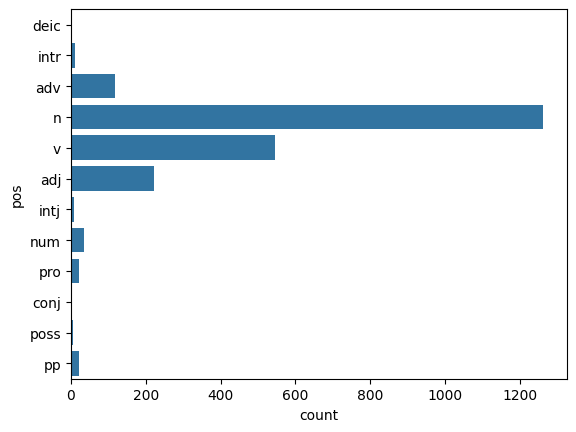

In [17]:
sns.countplot(lexicon['pos'])

## Assembling Final Training Dataset

In [6]:

builder = AtakapaDatasetBuilder()

# 1. Load the files
# Assuming they are converted to CSV or read directly via read_excel
print("Loading data files...")
df_texts = pd.read_excel('texts.xlsx')
df_corpus = pd.read_excel('atakapa_corpus_with_fixed_column.xlsx')
df_lexicon = pd.read_excel('atakapa_lexicon_final.xlsx')

# 2. Extract and format Tier 1: The 9 Glossed Texts
print("Processing Glossed Texts...")
hf_texts = builder.build_from_dataframe(
    df=df_texts, 
    atakapa_col='Gloss_Fixed', 
    gloss_col='en_Gloss',
    is_pre_segmented=True
)

# 3. Extract and format Tier 2: The Corpus Examples
print("Processing Corpus Examples...")
hf_corpus = builder.build_from_dataframe(
    df=df_corpus, 
    atakapa_col='Gloss.5_Fixed', 
    gloss_col='Gloss.6',
    is_pre_segmented=True
)

# 4. Extract and format Tier 3: The Lexicon (Vocabulary Flashcards)
print("Processing Lexicon...")
hf_lexicon = builder.build_from_dataframe(
    df=df_lexicon, 
    atakapa_col='apq', 
    gloss_col='en',
    is_pre_segmented=True
)

# 5. Merge all tiers into the final training object
final_training_dataset = concatenate_datasets([hf_texts, hf_corpus, hf_lexicon])

# Shuffle the dataset so the model doesn't just memorize the dictionary first
final_training_dataset = final_training_dataset.shuffle(seed=42)

print(f"\nSuccessfully built a dataset with {len(final_training_dataset)} training pairs.")

Loading data files...
Processing Glossed Texts...
Processing Corpus Examples...
Processing Lexicon...

Successfully built a dataset with 2839 training pairs.


In [7]:
final_training_dataset.to_json("atakapa_training_dataset.jsonl", orient="records", lines=True)

Creating json from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

439942